# Filtracja bilateralna

## Konwolucja obrazu z filtrem o zadanych współczynnikach

Splot (konwolucję) obrazu wejściowego $I$ z filtrem $\psi$ dla ustalonego punktu obrazu $\mathbf{x}$ można przedstawić następująco:

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||)I(\mathbf{p})
\end{equation}

gdzie:
- $\hat{I}$ jest obrazem wynikowym (przefiltrowanym),
- $W_N = \sum_y \psi(y)$ jest parametrem normalizującym współczynniki filtra $\psi$,
- $||\cdot||$ jest odległością między punktami obrazu $\mathbf{x}$ i $\mathbf{p}$ według ustalonej metryki (np. norma $L_2$). Uwaga, proszę pamiętać, że zarówno $\mathbf{x}$, jak i $\mathbf{p}$ to współrzędne przestrzenne,
- $\eta(\mathbf{x})$ jest otoczeniem punktu $\mathbf{x}$.

Funkcja $\psi$ decyduje o charakterze filtracji. Dla filtru Gaussowskiego:

\begin{equation}
\psi(y) = G_{\delta_s}(y)
\end{equation}

gdzie: $G_{\delta_s}(y)$ jest funkcją Gaussa z parametrem skali $\delta_s$.

Opisaną powyżej filtrację realizowaliśmy w ramach ćwiczenia "Przetwarzanie wstępne. Filtracja kontekstowa."

## Filtracja bilateralna

Wadą klasycznego splotu jest brak adaptacji współczynników filtra do lokalnego otoczenia $\eta(\mathbf{x})$ filtrowanego punktu $\mathbf{x}$.
Oznacza to wykorzystanie tych samych współczynników filtra $\psi$ niezależnie od tego czy otoczenie jest względnie jednorodne lub zawiera krawędzie obiektów (w tym przypadku dochodzi do "rozmywania" krawędzi).
Filtracja bilateralna uwzględnia lokalne otoczenie filtrowanego punktu, w ten sposób, że parametry filtra zmieniają się w zależności od "wyglądu" otocznia.


Współczynniki filtra obliczane są na podstawie odległości filtrowanego punktu $\mathbf{x}$ od każdego punktu otoczenia $\mathbf{p}$ w dziedzinie przestrzennej obrazu (tak jak przy typowym filtrze np. Gaussa) oraz odległości punktów w przeciwdziedzinie obrazu (np. na podstawie różnicy w jasności pikseli dla obrazu w odcieniach szarości):

\begin{equation}
\hat{I}(\mathbf{x}) = \frac{1}{W_N}\sum_{\mathbf{p} \in \eta(\mathbf{x})} \psi(||\mathbf{p}-\mathbf{x}||) \gamma(|I(\mathbf{p}) - I(\mathbf{x})|) I(\mathbf{p})
\end{equation}
gdzie:
- $W_N$ jest współczynnikiem normalizującym filtr,
- $\gamma$ jest funkcją odległości w przeciwdziedzinie obrazu, np. $\gamma(y)=\exp(-\frac{y^2}{2\delta_r^2})$
- parametr $\delta_r$ jest utożsamiany z poziomem szumu w obrazie i należy go dobrać w sposób empiryczny.

Proszę chwilę zastanowić się nad powyższym równaniem, w szczególności nad funkcją $\gamma$. Proszę wyznaczyć, jaka będzie wartość funkcji dla pikseli podobnych (różnica 0, 1, 2), a skrajnie różnych (255, 200).

##  Realizacja ćwiczenia

### Wczytanie danych

1. Wczytaj dane z pliku *MR_data.mat*. W tym celu wykorzystaj funkcję `loadmat` z pakietu scipy:
        from scipy.io import loadmat
        mat = loadmat('MR_data.mat')

2. Wczytany plik zawiera 5 obrazów: *I_noisefree*, *I_noisy1*, *I_noisy2*, *I_noisy3* oraz *I_noisy4*. Odczytać je można w następujący sposób:
        Input = mat['I_noisy1']

3.Wyświetl wybrany obraz z pliku *MR_data.mat*. Zagadka - co to za obrazowanie medyczne?

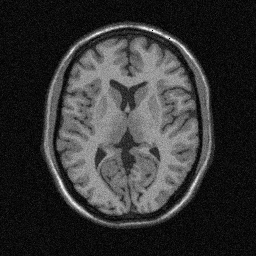

In [60]:
from google.colab.patches import cv2_imshow
from matplotlib import pyplot as plt
from scipy.io import loadmat
import numpy as np
import requests
import cv2
import os


url = "https://raw.githubusercontent.com/vision-agh/poc_sw/master/07_Bilateral/"

fileNames = ["MR_data.mat"]
for fileName in fileNames:
    if not os.path.exists(fileName):
        r = requests.get(url + fileName, allow_redirects=True)
        open(fileName, "wb").write(r.content)


mat = loadmat("MR_data.mat")
Input = mat["I_noisy1"].astype("uint8")
I_noisefree = mat["I_noisefree"].astype("uint8")
I_noisy1 = mat["I_noisy1"].astype("uint8")
I_noisy2 = mat["I_noisy2"].astype("uint8")
I_noisy3 = mat["I_noisy3"].astype("uint8")
I_noisy4 = mat["I_noisy4"].astype("uint8")
cv2_imshow(Input)

### "Klasyczna" konwolucja



1. Zdefiniuj parametry filtra Gaussowskiego: rozmiar okna i wariancję $\delta_S$.

In [61]:
window_size = 5
sigma = 1.5

2. Oblicz współczynniki filtra na podstawie zdefiniowanych parametrów (najprościej w ramach podwójnej pętli for).

In [62]:
def fgaussian(size, sigma):
    m = n = size
    h, k = m // 2, n // 2
    x, y = np.mgrid[-h : h + 1, -k : k + 1]
    g = np.exp(-(x**2 + y**2) / (2 * sigma**2))
    return g / g.sum()


def mesh(fun, size):
    fig = plt.figure()
    ax = fig.add_subplot(111, projection="3d")

    X = np.arange(-size // 2, size // 2, 1)
    Y = np.arange(-size // 2, size // 2, 1)
    X, Y = np.meshgrid(X, Y)
    Z = fun

    ax.plot_surface(X, Y, Z)

    plt.show()


gaussian_kernel = fgaussian(window_size, sigma)

2. Sprawdź ich poprawność i zwizualizuj filtr (tak jak w ćwiczeniu pt. "Przetwarzanie wstępne. Filtracja kontekstowa.").

Suma elementów filtra: 1.0


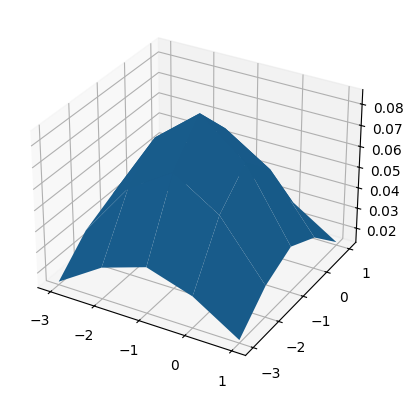

In [63]:
print(f"Suma elementów filtra: {np.sum(gaussian_kernel)}")

mesh(gaussian_kernel, window_size)

3. Wykonaj kopię obrazu wejściowego: `IConv = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentem tej funkcji są aktualnie przetwarzane okno i współczynniki filtra.
7. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.

In [64]:
def convolution(image, window_size, sigma):
    gaussian_kernel = fgaussian(window_size, sigma)
    Iconv = image.copy()
    M, N = Iconv.shape

    def convolute(context, kernel):
        return np.sum(context * kernel)

    for i in range(window_size // 2, M - window_size // 2):
        for j in range(window_size // 2, N - window_size // 2):
            context = image[
                i - window_size // 2 : i + window_size // 2 + 1,
                j - window_size // 2 : j + window_size // 2 + 1,
            ]
            Iconv[i, j] = convolute(context, gaussian_kernel)

    return Iconv.astype("uint8")

8. Wyświetl wynik filtracji.
9. Porównaj wynik z obrazem oryginalnym.

In [65]:
def plot_image_filtered_and_diff(image, conv):
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    diff = cv2.absdiff(image, conv)

    axes[0].imshow(image, cmap="gray")
    axes[1].imshow(conv, cmap="gray")
    axes[2].imshow(diff, cmap="gray")

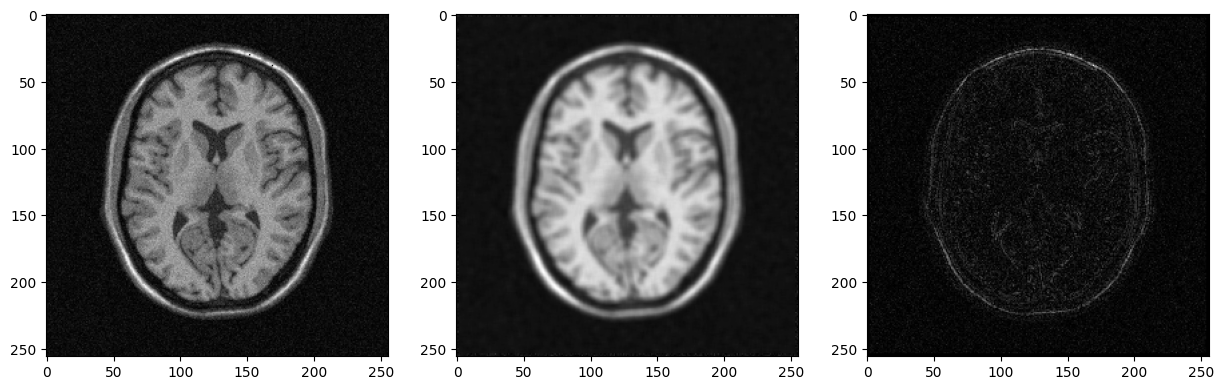

In [73]:
Iconv = convolution(Input, 5, 10)
plot_image_filtered_and_diff(Input, Iconv)

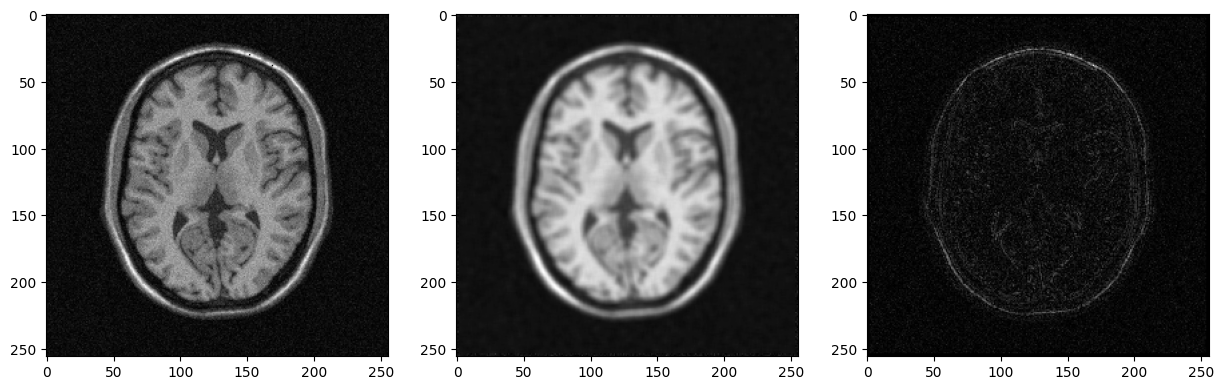

In [74]:
Iconv = convolution(I_noisy1, 5, 10)
plot_image_filtered_and_diff(I_noisy1, Iconv)

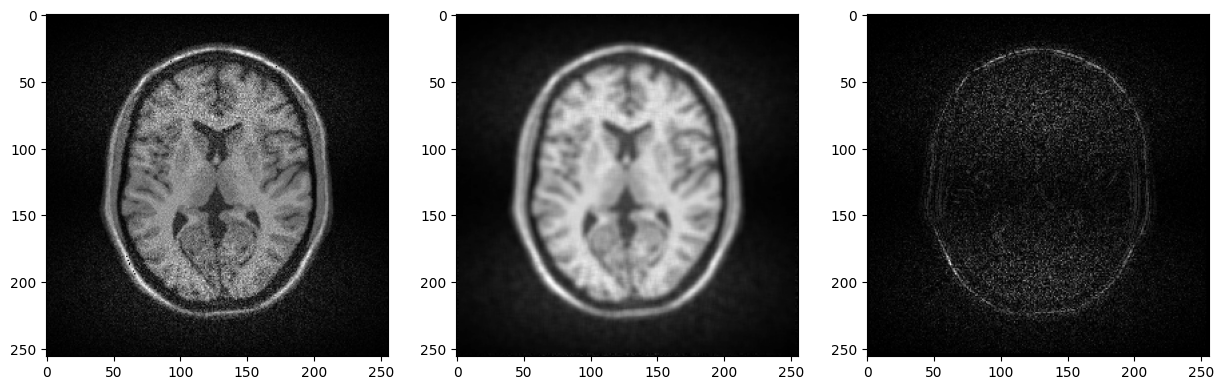

In [75]:
Iconv = convolution(I_noisy2, 5, 10)
plot_image_filtered_and_diff(I_noisy2, Iconv)

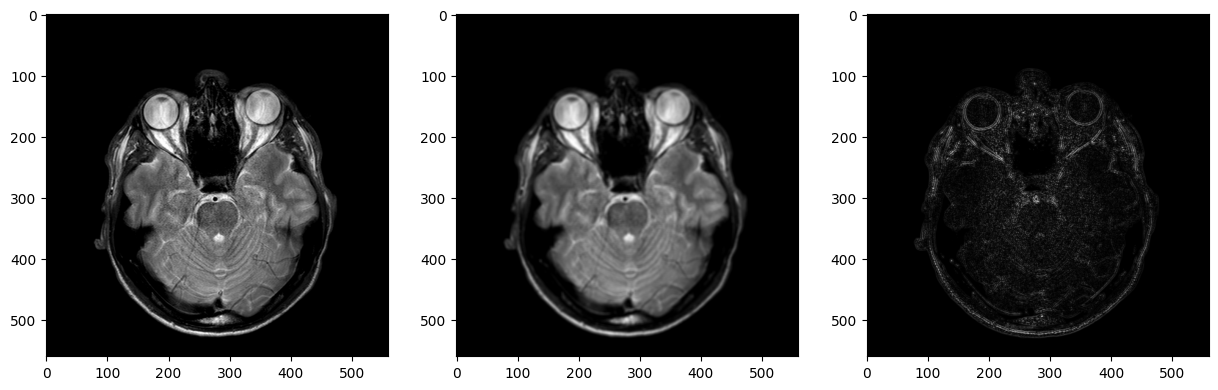

In [76]:
Iconv = convolution(I_noisy3, 5, 10)
plot_image_filtered_and_diff(I_noisy3, Iconv)

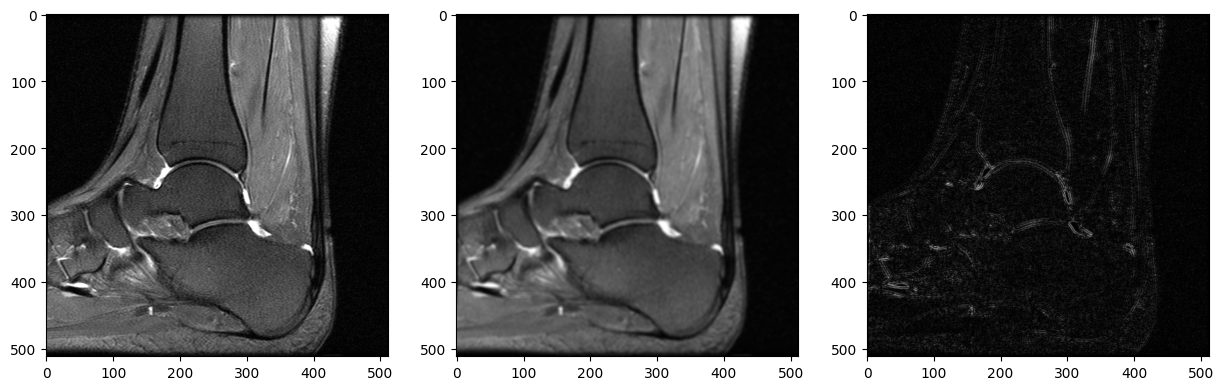

In [77]:
Iconv = convolution(I_noisy4, 5, 10)
plot_image_filtered_and_diff(I_noisy4, Iconv)

### Filtracja bilateralna

1. Zdefiniuj dodatkowy parametr: wariancję $\delta_R$.
3. Wykonaj kopię obrazu wejściowego: `IBilateral = Input.copy()`
4. Wykonaj podwójną pętlę po obrazie. Pomiń ramkę, dla której nie jest zdefiniowany kontekst o wybranej wielkości.
5. W każdej iteracji stwórz dwuwymiarową tablicę zawierającą aktualny kontekst.
6. Napisz funkcję, która będzie obliczała nową wartość piksela.
Argumentami funkcji są aktualnie przetwarzane okno, współczynniki filtra gausowskiego (takie same jak wcześniej) i wariancja $\delta_R$.
7. Oblicz odległość w przeciwdziedzinie (dla wartości pikseli).
8. Oblicz funkcję Gaussa dla obliczonych odległości z zadanym parametrem.
9. Wykonaj normalizację obliczonych współczynników.
10. Obliczoną wartość przypisz do odpowiedniego piksela kopii obrazu wejściowego.
11. Wyświetl wynik filtracji.
12. Porównaj wynik z obrazem oryginalnym.

In [71]:
def biliteral(image, window_size, sigmaColor, sigmaSpace):
    gaussian_kernel = fgaussian(window_size, sigmaSpace)
    IBiliteral = image.copy()
    M, N = image.shape

    def gamma(x):
        x = np.int64(x)
        return np.exp(-(x**2) / (2 * sigmaColor**2))

    def convolute(context, kernel, sigmaColor, center_pixel):
        intensity_diff = context - center_pixel
        biliteral_kernel = kernel * gamma(intensity_diff)

        return np.sum(context * biliteral_kernel) / biliteral_kernel.sum()

    for i in range(window_size // 2, M - window_size // 2):
        for j in range(window_size // 2, N - window_size // 2):
            context = image[
                i - window_size // 2 : i + window_size // 2 + 1,
                j - window_size // 2 : j + window_size // 2 + 1,
            ]
            IBiliteral[i, j] = convolute(
                context, gaussian_kernel, sigmaColor, image[i, j]
            )

    return IBiliteral.astype("uint8")

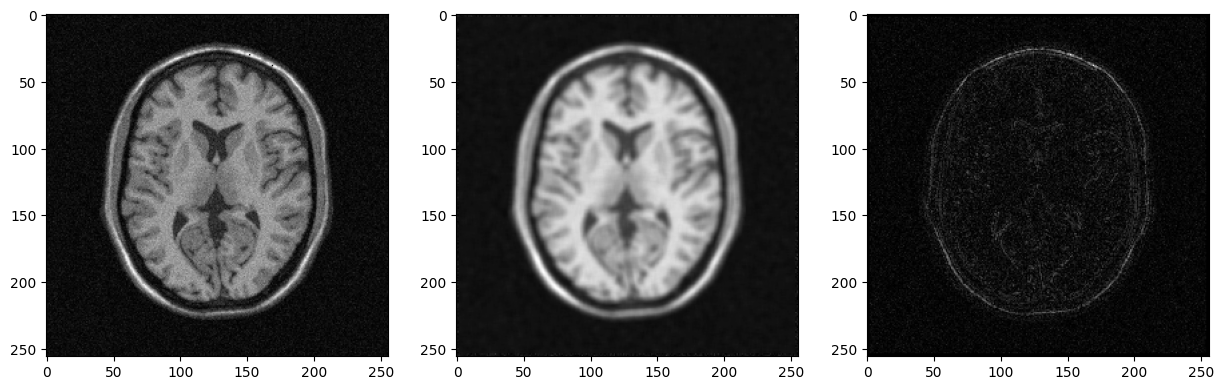

In [78]:
Iconv = convolution(Input, 5, 10)
plot_image_filtered_and_diff(Input, Iconv)

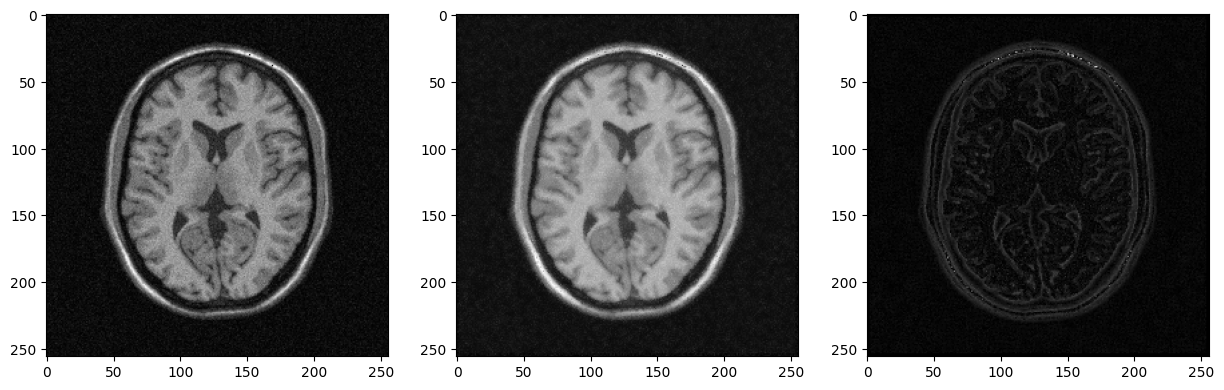

In [81]:
IBiliteral1 = biliteral(Input, 5, sigmaSpace=20, sigmaColor=50)
plot_image_filtered_and_diff(Input, IBiliteral1)

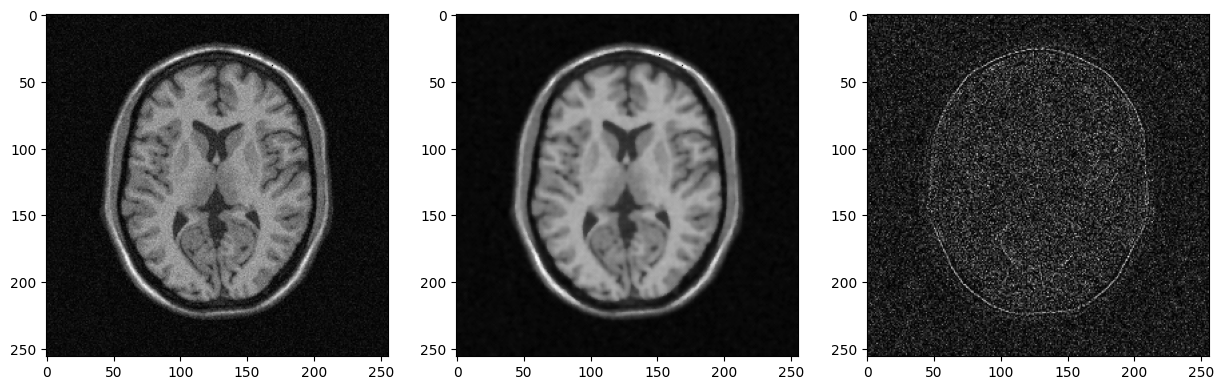

In [88]:
IBiliteral2 = cv2.bilateralFilter(Input, d=5, sigmaSpace=20, sigmaColor=50)
plot_image_filtered_and_diff(Input, IBiliteral2)

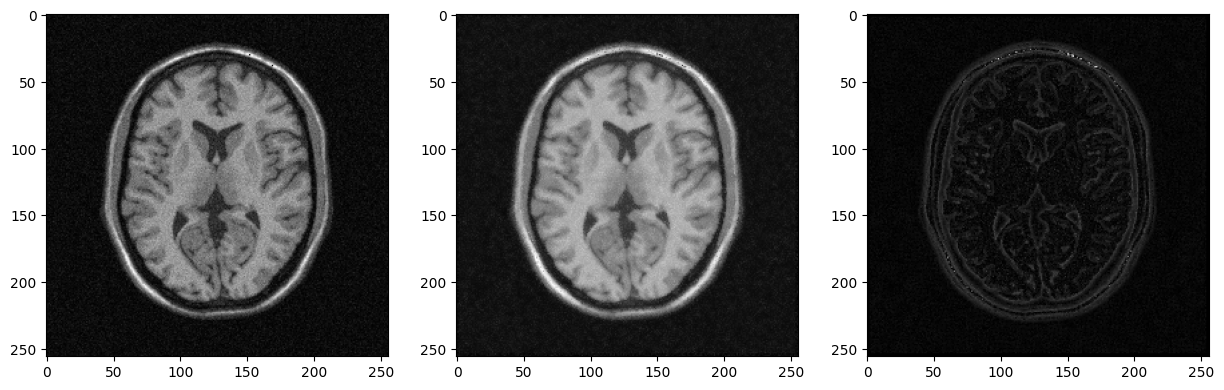

In [89]:
IBiliteral = biliteral(I_noisy1, 5, sigmaSpace=20, sigmaColor=50)
plot_image_filtered_and_diff(I_noisy1, IBiliteral)

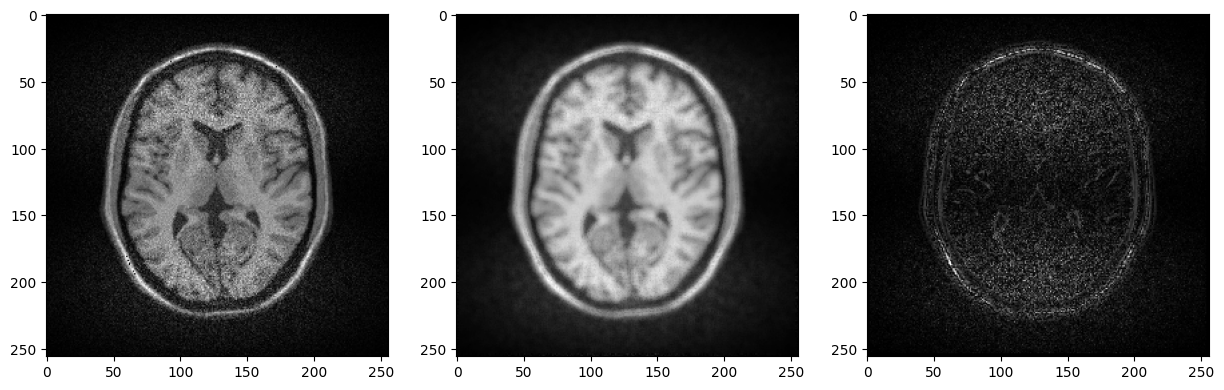

In [100]:
IBiliteral = biliteral(I_noisy2, 5, sigmaSpace=20, sigmaColor=150)
plot_image_filtered_and_diff(I_noisy2, IBiliteral)

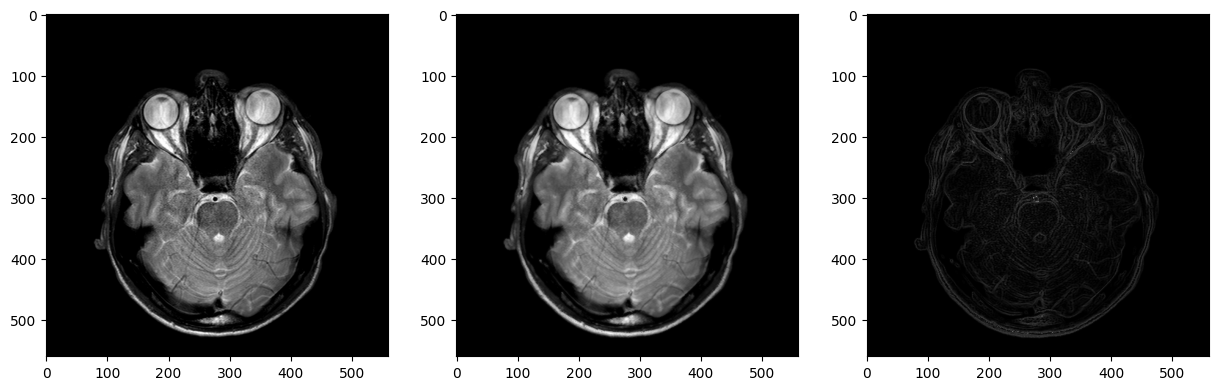

In [98]:
IBiliteral = biliteral(I_noisy3, 5, sigmaSpace=20, sigmaColor=50)
plot_image_filtered_and_diff(I_noisy3, IBiliteral)

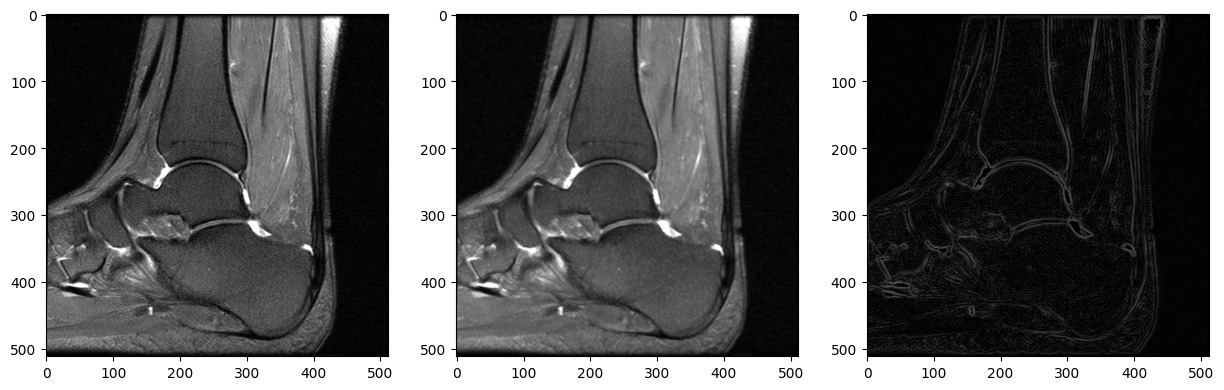

In [99]:
IBiliteral = biliteral(I_noisy4, 5, sigmaSpace=20, sigmaColor=50)
plot_image_filtered_and_diff(I_noisy4, IBiliteral)

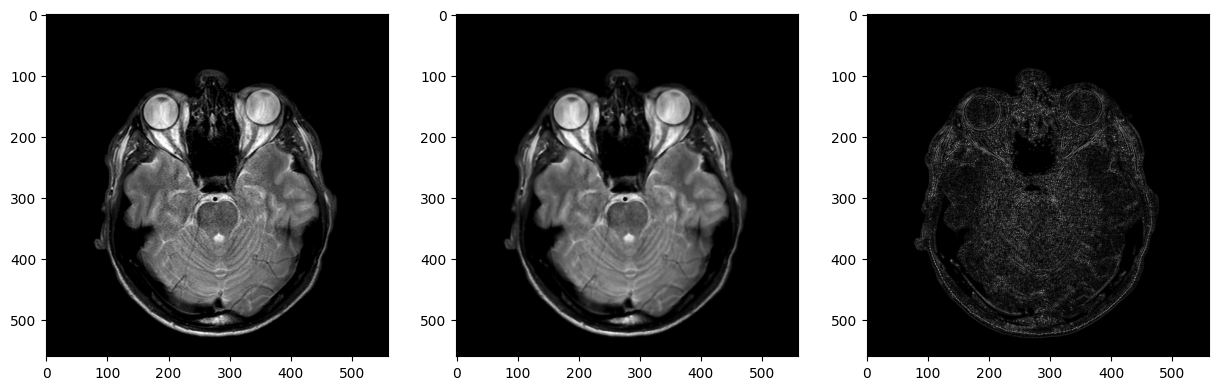

In [57]:
IBiliteral = cv2.bilateralFilter(I_noisy3, d=5, sigmaColor=50, sigmaSpace=20)
plot_image_filtered_and_diff(I_noisy3, IBiliteral)